<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project-5/NLP_part1%262_bis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [107]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import re
import time

import wikipediaapi

pd.options.display.max_columns = 100

import nltk
# nltk.download('omw-1.4')
nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [109]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [110]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [111]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [112]:
df.iloc[42630]['text']

'gary griffin born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977 griffin moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu griffin toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000 griffin served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos griffin has produced an eclectic roster of artists most notably micky dolenz of the monkees and political satiri

In [113]:
# Load dataset (this might take a moment given the size)
df = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv")
df

def fast_mask_name(row):
    text = str(row['text'])
    name = str(row['name'])

    # Split the name into individual tokens (e.g., "Gary", "Griffin")
    name_parts = name.split()

    # Replace the full name and its individual parts with empty space or a generic token
    # We use regex boundaries (\b) to ensure we don't accidentally mask parts of other words
    for part in name_parts:
        if len(part) > 2: # Avoid masking tiny initials like "A."
            text = re.sub(rf'\b{re.escape(part)}\b', '', text, flags=re.IGNORECASE)

    return text

print(f"Masking names across {df.index.size} rows...")
# use .apply() or look into 'pandarallel' / 'dask' if this takes more than a couple of minutes
df['cleaned_text'] = df.apply(fast_mask_name, axis=1)

Masking names across 42786 rows...


In [114]:
# Use .iloc[0] to grab the text of the person of interest (Gary Griffin)
# This looks at the 42630th row, and extracts whatever is in the 'text' column
griffin_full_text = df["cleaned_text"].iloc[42630]

# Create a TextBlob of his full text profile
full_blob = TextBlob(griffin_full_text)
full_blob


TextBlob("  born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977  moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu  toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000  served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos  has produced an eclectic roster of artists most notably micky dolenz of the monkees and political satirist harry shearer he also copro

In [115]:
size = len(full_blob)
size

1651

In [116]:
# convert the text for Gary Griffin into a string to be able to vectorize it. full_blob is a textblob.
full_blob_string = [str(s) for s in full_blob.sentences]
full_blob_string

['  born october 26 1951 in cincinnati ohio is an american musician best known for performing as a keyboardist and vocalist with the beach boys brian wilson jan and dean and the surf city allstarsgriffin grew up in cincinnati and attended miami university and the university of cincinnati college conservatory of music where he majored in piano and music theoryin 1977  moved to los angeles where he was hired as an organist by the beach boys joining them for the recording of their warner bros album miu  toured and recorded with jan and dean throughout the 80s and 90s and has appeared on several television shows most notably general hospital and full house in 2000  served as music director for the emmynominated television miniseries the beach boys an american family for abc he also appeared in two roles in the film which was produced by john stamos  has produced an eclectic roster of artists most notably micky dolenz of the monkees and political satirist harry shearer he also coproduced th

In [117]:
size_1 = len(full_blob_string)
size_1

1

In [118]:
#vectorizing full_blob_string
vectorizer = CountVectorizer(stop_words="english")
bow_griffin = vectorizer.fit_transform(full_blob_string)

In [119]:
# to check the code above worked.
print("BoW Griffin Shape:", bow_griffin.shape)
print("Vocabulary Preview:", list(vectorizer.vocabulary_.keys())[:10])

BoW Griffin Shape: (1, 125)
Vocabulary Preview: ['born', 'october', '26', '1951', 'cincinnati', 'ohio', 'american', 'musician', 'best', 'known']


In [120]:
# Make sure there are no missing values in the text column
# (CountVectorizer will error out if it encounters a NaN/Float value)
df['cleaned_text'] = df["cleaned_text"].fillna("")

In [121]:
# Initialize the CountVectorizer
# stop_words='english' removes common filler words like 'the', 'is', 'and'
vectorizer = CountVectorizer(stop_words="english")

In [122]:
# Transform the entire text column straight into a Bag of Words matrix
# it works on all rows simultaneously!
bow_alltext = vectorizer.fit_transform(df["cleaned_text"])

In [123]:
# --- VERIFY THE OUTPUT ---
print("--- VECTORIZATION COMPLETE ---")
print(f"Total number of people (rows): {bow_alltext.shape[0]}")
print(f"Total number of unique words (columns): {bow_alltext.shape[1]}")
print(f"Type of matrix generated: {type(bow_alltext)}")

--- VECTORIZATION COMPLETE ---
Total number of people (rows): 42786
Total number of unique words (columns): 424252
Type of matrix generated: <class 'scipy.sparse._csr.csr_matrix'>


In [124]:
# Transform BoW to TF-IDF
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(bow_alltext)

# Fit your KNN model on the matrix
knn = NearestNeighbors(n_neighbors=11, metric="cosine")
knn.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [125]:
distances, indices = knn.kneighbors(
  X = tfidf_matrix[42630],#reference cell
  n_neighbors = 11,# what are the 10 more close to it
)

In [126]:
indices

array([[42630, 13115, 10018, 18423, 14151, 28221, 38744, 32680, 22121,
        21483, 17075]])

In [127]:
distances

array([[0.        , 0.73748106, 0.75961073, 0.76639634, 0.81113528,
        0.8376671 , 0.84143898, 0.84358229, 0.85781008, 0.86237914,
        0.86289869]])

In [128]:
full_blob.sentiment

Sentiment(polarity=0.246875, subjectivity=0.396875)

In [129]:
import pandas as pd

# List of neighbor indices (including Gary Griffin and the 10 closest people)
neighbor_indices = [
    42630,
    13115,
    10018,
    18423,
    14151,
    28221,
    38744,
    32680,
    22121,
    21483,
    17075
]

# Using .iloc extract names
# Use .copy() to ensure it's a completely independent, new DataFrame
df_closest = df.iloc[neighbor_indices].copy()

# Only keep the index and the 'name' column
# Reset the index to bring the original row numbers out into an explicit column
df_closest_names = df_closest[["name"]].reset_index().reset_index(names = ['rank'])
df_closest_names

,rank,index,name
0,0,42630,Gary Griffin (musician)
1,1,13115,John Cowsill
2,2,10018,Scott Totten
3,3,18423,Mike Love
4,4,14151,Phil Bardowell
5,5,28221,Darian Sahanaja
6,6,38744,David Leaf
7,7,32680,Brian Wilson
8,8,22121,Randell Kirsch
9,9,21483,Nat Young


### Part 2

In [130]:
# https://en.wikipedia.org/wiki/Gary_Griffin_(musician)
# target = 'Gary_Griffin (musician)'
target = df_closest_names['name'].iloc[0]
wikip = wikipediaapi.Wikipedia('interest')
page_ex = wikip.page(target)
target_text = page_ex.text
target_text

'Gary Griffin (born October 26, 1951, in Cincinnati, Ohio) is an American musician, best known for performing as a keyboardist and vocalist with The Beach Boys, Brian Wilson, Jan and Dean and The Surf City Allstars.\n\nEarly career\nGriffin grew up in Cincinnati and attended Miami University and the University of Cincinnati – College-Conservatory of Music, where he majored in piano and music theory.\nIn 1977, Griffin moved to Los Angeles where he was hired as an organist by The Beach Boys, joining them for the recording of their Warner Brothers album M.I.U., as well as several other related productions, Almost Summer by spin-off group Celebration and Weavings by jazz saxophonist Charles Lloyd.\nGriffin toured and recorded with Jan and Dean throughout the 1980s and 1990s, and has appeared as a regular on several television shows, most notably General Hospital and Full House. In 2000, Griffin served as music director, alongside producer John Stamos, for the Emmy-nominated television mini

In [131]:
# create the TextBlob
w_blob = TextBlob(target_text)
w_blob

TextBlob("Gary Griffin (born October 26, 1951, in Cincinnati, Ohio) is an American musician, best known for performing as a keyboardist and vocalist with The Beach Boys, Brian Wilson, Jan and Dean and The Surf City Allstars.

Early career
Griffin grew up in Cincinnati and attended Miami University and the University of Cincinnati – College-Conservatory of Music, where he majored in piano and music theory.
In 1977, Griffin moved to Los Angeles where he was hired as an organist by The Beach Boys, joining them for the recording of their Warner Brothers album M.I.U., as well as several other related productions, Almost Summer by spin-off group Celebration and Weavings by jazz saxophonist Charles Lloyd.
Griffin toured and recorded with Jan and Dean throughout the 1980s and 1990s, and has appeared as a regular on several television shows, most notably General Hospital and Full House. In 2000, Griffin served as music director, alongside producer John Stamos, for the Emmy-nominated television 

In [132]:
# determine the sentiment for GG for the article in Wikipedia
w_blob.sentiment

Sentiment(polarity=0.18712910353535353, subjectivity=0.40941506410256406)

In [133]:
# to remove GG from the df from Part 1, 10-row DataFrame containing only the neighbors
# df_neighbors_only = df_closest_names.drop(index=0).reset_index(drop=True)
df_neighbors_only = df_closest_names.reset_index(drop=True)
df_neighbors_only

,rank,index,name
0,0,42630,Gary Griffin (musician)
1,1,13115,John Cowsill
2,2,10018,Scott Totten
3,3,18423,Mike Love
4,4,14151,Phil Bardowell
5,5,28221,Darian Sahanaja
6,6,38744,David Leaf
7,7,32680,Brian Wilson
8,8,22121,Randell Kirsch
9,9,21483,Nat Young


In [134]:
# df_closest_names
# create a for loop to through the column 'name' on the df listing all closest names
scraped_texts = [target_text]
for index, row in df_closest_names.iloc[1:].iterrows():
    name = row["name"]

    # Request the specific page from Wikipedia
    page = wikip.page(name)
    # Check if the page actually exists
    if page.exists():
        print(f"Success: Found and collecting text for '{name}'...")
        # page.summary gets just the introduction, page.text gets the FULL article text
        scraped_texts.append(page.text)
    else:
        print(f"Warning: Could not find an exact Wikipedia page for '{name}'")
        scraped_texts.append("Page not found on Wikipedia")

    # Pause for 0.5 seconds between requests
    # This prevents your script from slamming Wikipedia's servers too hard
    time.sleep(0.5)

Success: Found and collecting text for 'John Cowsill'...
Success: Found and collecting text for 'Scott Totten'...
Success: Found and collecting text for 'Mike Love'...
Success: Found and collecting text for 'Darian Sahanaja'...
Success: Found and collecting text for 'David Leaf'...
Success: Found and collecting text for 'Brian Wilson'...
Success: Found and collecting text for 'Randell Kirsch'...
Success: Found and collecting text for 'Nat Young'...
Success: Found and collecting text for 'Matti Herrera Bower'...


In [135]:
df_closest_names

,rank,index,name
0,0,42630,Gary Griffin (musician)
1,1,13115,John Cowsill
2,2,10018,Scott Totten
3,3,18423,Mike Love
4,4,14151,Phil Bardowell
5,5,28221,Darian Sahanaja
6,6,38744,David Leaf
7,7,32680,Brian Wilson
8,8,22121,Randell Kirsch
9,9,21483,Nat Young


In [136]:
%%capture
!pip3 install wikipedia-api

In [137]:
import wikipediaapi

In [138]:
df_closest_names["Full_Wikipedia_Text"] = scraped_texts

print("\n--- COLLECTION COMPLETE ---")
print(df_neighbors_only.head(3))


--- COLLECTION COMPLETE ---
   rank  index                     name
0     0  42630  Gary Griffin (musician)
1     1  13115             John Cowsill
2     2  10018             Scott Totten


In [139]:
tf_idf_matrix = TfidfVectorizer(stop_words = 'english')
tf_idf = tf_idf_matrix.fit_transform(df_closest_names['Full_Wikipedia_Text'])
tf_idf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7669 stored elements and shape (11, 4896)>

In [140]:
nn = NearestNeighbors().fit(tf_idf)

In [141]:
distances, indices = nn.kneighbors(
  X = tf_idf[0],#reference cell
  n_neighbors = 11,# what are the 10 more close to it
)

In [142]:
distances

array([[0.        , 1.21685429, 1.23757197, 1.25335199, 1.298819  ,
        1.30033582, 1.33519564, 1.34563517, 1.3708032 , 1.39195614,
        1.41421356]])

In [143]:
indices

array([[ 0,  2,  7,  3,  1,  5,  6,  8, 10,  9,  4]])

In [144]:
rank_df = df_neighbors_only.iloc[indices[0]].reset_index(drop = True).reset_index(names = ['wiki_rank'])
rank_df

,wiki_rank,rank,index,name
0,0,0,42630,Gary Griffin (musician)
1,1,2,10018,Scott Totten
2,2,7,32680,Brian Wilson
3,3,3,18423,Mike Love
4,4,1,13115,John Cowsill
5,5,5,28221,Darian Sahanaja
6,6,6,38744,David Leaf
7,7,8,22121,Randell Kirsch
8,8,10,17075,Matti Herrera Bower
9,9,9,21483,Nat Young


In [145]:
rank_df['delta'] = rank_df['rank']- rank_df['wiki_rank']
rank_df

,wiki_rank,rank,index,name,delta
0,0,0,42630,Gary Griffin (musician),0
1,1,2,10018,Scott Totten,1
2,2,7,32680,Brian Wilson,5
3,3,3,18423,Mike Love,0
4,4,1,13115,John Cowsill,-3
5,5,5,28221,Darian Sahanaja,0
6,6,6,38744,David Leaf,0
7,7,8,22121,Randell Kirsch,1
8,8,10,17075,Matti Herrera Bower,2
9,9,9,21483,Nat Young,0


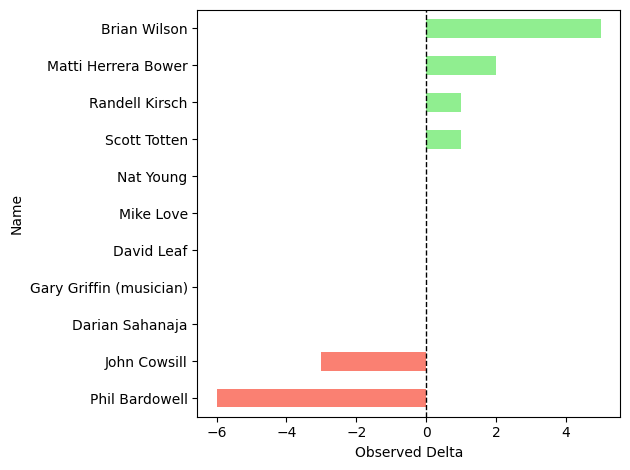

In [146]:
# 1. Sort your DataFrame
sorted_df = rank_df.sort_values(by='delta')

# This creates a list: 'salmon' if the delta is negative, 'lightgreen' if positive
colors = ['salmon' if val < 0 else 'lightgreen' for val in sorted_df['delta']]

# 3. Plot and pass the 'colors' list into the color parameter
ax = sorted_df.plot(
    kind='barh',
    x='name',
    y='delta',
    color=colors,  # <--- Use the dynamic list here instead of the hardcoded list
    legend=False
)

# 4. Add your customizations and save
ax.axvline(x=0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Observed Delta')
ax.set_ylabel('Name')
plt.tight_layout()

# 5. Save and show
plt.savefig('knn_wikipedia_delta.png', bbox_inches='tight', dpi=300)
plt.show()